# ArcFace Loss (Additive Angular Margin Loss)

## Теория ArcFace

В случае с обучением на задачу классификации первая подходящая лосс-функция, которая нам приходит в голову — Cross-Entropy. И на ней действительно можно обучать сеть для распознавания лиц. Но за много лет люди придумали более хитрые трюки, которые делают обучение сети для распознавания лиц более эффективным. Одним из лучших подходов считается ArcFace (Additive Angular Margin).


**Как устроен ArcFace**:

Стандартные SoftMax + кросс-энтропия (CE) выглядят так:

$$L_{CE} = \frac{-1}{N}\sum_1^N \frac{e^{W_{y_i}^{T}x_i + b_{y_i}}}{\sum^n_{j=1}e^{W_j^Tx_i+b_j}},$$

здесь:
- $x_i \in \mathbb{R^d}$ — вектор $i$-го элемента обучающей выборки перед последним полносвязным слоем сети. $y_i$ — класс этого элемента;
- $W_j \in \mathbb{R^d}$ — j-ый столбец матрицы весов последнего слоя сети (т.е. слоя, который производит итоговую классификацю входящего объекта);
- $b_j \in \mathbb{R^d}$ — j-ый элемент вектора байеса последнего слоя сети;
- $N$ — batch size;
- $n$ — количество классов.


Хотя этот лосс работает хорошо, он явным образом не заставляет эмбеддинги $x_i$ элементов, принадлежащих одному классу, быть близкими друг к другу по расстоянию. И не заставляет эмбеддинги элементов, принадлежащих разным классам, быть далеко друг от друга. Все, что хочет этот лосс — чтобы на основе эмбеддингов $x_i$ можно было хорошо классифицировать элементы, никакие ограничений на расстояния между эмбеддингами $x_i$ он не вводит.

Из-за этого у нейросетей для распознавания лиц, которые обучены на обычном CE loss, бывают проблемы с распознаванием лиц, которые сильно отличаются от лиц того же человека разными доп. атрибутами (шляпа/прическа/очки и т.п.). Просто эмбеддинг для таких лиц получается довольно далек по расстоянию от других эмбеддингов лиц этого же человека.

Давайте теперь немного поправим формулу:
- уберем байес последнего слоя, т.е. сделаем $b_j=0$;
- нормализуем веса последнего слоя: ||$W_j$|| = 1;
- нормализуем эмбеддинги: ||$x_i$|| = 1. Перед подачей их на вход последнему слою (т.е. перед умножением на матрицу $W_j$) умножим их на гиперпараметр s. По сути, мы приводим норму всех эмбеддингов к s. Смысл этого гиперпараметра в том, что, возможно, сети проще будет классифицировать эмбеддинги, у которых не единичная норма.

Нормализация приводит к тому, что эмбеддинги распределяются по сфере единичного радиуса (и сфере радиуса s после умножения на гиперпараметр s). И итоговые предсказания сети после последнего слоя зависят только от угла между эмбеддингами $x_i$ и выученных весов $W_j$. От нормы эмбеддинга $x_i$ они больше не зависят, т.к. у всех эмбеддингов они теперь одинаковые.

Получается, в степени экспоненты у нас останется выражение $s W_{y_i}^{T}x_i$, которое можно переписать в виде  $s W_{y_i}^{T}x_i = s ||W_{y_i}||\cdot ||x_i|| \cdot cos\Theta_{y_i}$. Тут $\Theta_{y_i}$ — это угол между векторами $W_{y_i}$ и $x_i$. Но так как мы сделали нормы $W_{y_i}$ и $x_i$ единичными, то все это выражение просто будет равно $s cos\Theta_{y_i}$.

В итоге мы получим следующую формулу лосса:

$$L = \frac{-1}{N}\sum_1^N \frac{e^{s\ cos\Theta_{y_i}}}{e^{s\ cos\Theta_{y_i}} + \sum^n_{j=1,\ j\ne y_i} e^{s\ cos\Theta_j}}$$


И последний шаг. Добавим еще один гиперпараметр $m$. Он называется additive angular margin penalty и заставляет эмбеддинги одного класса быть ближе друг к другу, а эмбеддинги разных классов — более далекими друг от друга.

В итоге получим вот что:

$$L_{ArcFace} = \frac{-1}{N}\sum_1^N \frac{e^{s\ cos(\Theta_{y_i} + m)}}{e^{s\ cos(\Theta_{y_i} + m)} + \sum^n_{j=1,\ j\ne y_i} e^{s\ cos\Theta_j}}$$

Это и есть ArcFace Loss с двумя  гиперпараметрами, s и m.

Получается, что ArcFace Loss завтавляет сеть выучивать эмбеддинги, распределенные по сфере радиуса s, причем чтобы эмбеддинги одного класса были ближе друг к другу, а эмбеддинги разных классов — более далеки друг от друга.

![ArcFace](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTKRR-YA_XR3yhIYBbkc8Zlbua0Q2WdM3gx_g&s)

**Важное пояснение:**

Строго говоря, ArcFace - не лосс, отдельный архитектурный модуль модификация SoftMax. Он реализует идею внесения геометрического отступа непосредственно в пространство признаков. Для обучения в качестве лосса используется обычная кросс-энтропия. Более конкретно по шагам:

1. Вы извлекаете эмбеддинги из бэкбона сети (предобученной модели, у которой обрезан FC-слой, если он был)
2. Эти эмбеддинги поступают в ArcFace-слой, который содержит векторы-центры для каждого класса (веса классификатора) и логику нормализации и добавления углового отступа
3. Для целевого класса ArcFace-слой преобразует косинус угла $\theta$ в $cos(\theta + m)$
4. Для остальных классов оставляет обычный косинус $cos(\theta)$
5. Эти модифицированные логиты подаются на вход стандартной функции Cross-Entropy
6. Градиенты от Cross-Entropy текут назад через ArcFace-слой к бэкбону, обучая модель извлекать эмбеддинги

Результат: модифицированные логиты с "жестким" разделением для целевого класса, а значит и более качественные эмбеддинги.

Схема:
```
[Изображение] → [Бэкбон] → [ЭМБЕДДИНГ] → [ArcFace] → [Логиты] → [CE Loss]
                    │                        │           │          
                   CNN                   Нормализация   Оценки
                                          + Angular    для всех
                                            Margin     классов
```

Для получения качественных эмбеддингов после обучения ArcFace-слой больше не нужен, и его обычно обрезают. Он нужен был только обучения модели, и поэтому часто ArcFace называю именно лоссом. Но стоит всегда держать в голове, что это некоторое упрощение, которое нужно лишь для того, чтобы проще формулировать мысли.

**Доп. литература по ArcFace Loss:**

Оригинальная статья: https://arxiv.org/pdf/1801.07698.pdf

## Другие лоссы

Кроме ArcFace, есть еще много разных вариантов лоссов для задачи Face Recognition. Некоторые из них можно найти, например, [тут](https://openaccess.thecvf.com/content_CVPRW_2020/papers/w48/Hsu_A_Comprehensive_Study_on_Loss_Functions_for_Cross-Factor_Face_Recognition_CVPRW_2020_paper.pdf). Вы можете попробовать реализовать другие лосс-функции в этом проекте в качестве дополнительного задания.

Кроме этого, можно миксовать лосс-функции. Например, обучать нейросеть на сумме ArcFace и TripletLoss. Иногда так выходит лучше, чем если обучать на каком-то одном лоссе.

# Датасет

В качестве датасета нужно использовать картинки из CelebA, выровненные при помощи своей модели из задания 1. Очень желательно их еще кропнуть таким образом, чтобы нейросети поступали на вход преимущественно только лица без какого либо фона, частей тела и прочего.

Если планируете делать дополнительное задание на Identificaton rate metric, то **обязательно разбейте заранее датасет на train/val или train/val/test.** Это нужно сделать не только на уровне кода, а на уровне папок, чтобы точно знать, на каких картинках модель обучалась, а на каких нет. Лучше заранее почитайте [ноутбук с заданием](https://colab.research.google.com/drive/15zuNdOupRFnG7oE-rFj9FsjoNTK6DYn5).

# План заданий

Итак, вот, что от вас требуется в этом задании:

* Выбрать модель (или несколько моделей) для обучения. Можно брать предобученные на ImageNet, но нельзя использовать модели, предобученные на задачу распознавания лиц.
* Обучить эту модель (модели) на CE loss. Добиться accuracy > 0.7.
* Реализовать ArcFace loss.
* Обучить модель (модели) на ArcFace loss. Добиться accuracy > 0.7.
* Написать небольшой отчет по обучению, сравнить CE loss и ArcFace loss.

**P.S. Не забывайте сохранять модели после обучения**

# 1. Подключаем необходимые библиотеки

In [1]:
import matplotlib.pyplot as plt
from pathlib import Path

import os, random, time, cv2, json
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve

import pandas as pd
from PIL import Image
from tqdm import tqdm
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.utils.data import random_split

import torchvision.transforms as T
import torchvision.models as models
from torchvision import transforms

from abc import ABC, abstractmethod

ROOT = "data"
OUTPUT_DIR = os.path.join(ROOT, "cropped_faces")
CSV_OUTPUT = os.path.join(ROOT, "selected_images.txt")
INDENTITY_TXT=os.path.join(ROOT, "identity_CelebA.txt")

device=torch.device( "cuda" if torch.cuda.is_available() else "cpu" )


## 1.1 Абстрактный класс ClassificationHead
для двух голов: Linear и ArcFace.

Данная архитектурная идея позволит потом менять:
```python
LinearHead
        |
        v
ArcFaceHead
        |
        v
CosFaceHead
        |
        v
SphereFaceHead
        |
        v
AdaFaceHead
```

In [2]:
class ClassificationHead(nn.Module, ABC):

    @abstractmethod
    def forward(self, embedding, labels=None):
        pass

# 2. Разбиение train/valid/test

Необходимо рассмотреть две задачи:
1. Классификация лиц с функцией потерь CrossEntropy
2. Face Recognition через ArcFace

Они используют один и тот же backbone, но оцениваются по-разному.

Для этих двух экспериментов (CrossEntropy для Face Recognition с использованием ArcFace) требования отличаются, поэтому необходимо сделать такой split, чтобы удовлетворить этим двум требованиям.

---

### 2.1. CrossEntropy обучение

Для CE задача выглядит так: `image → CNN → embedding → Linear(num_classes) → softmax`
Если, например, `identity=9343`, значит последний слой:
```python
nn.Linear(embedding_dim, 9343)
```
Поэтому train/valid/test должны иметь **одинаковый набор классов**:
<table>
  <tr>
    <th>Person A</th>
    <th>Person B</th>
    <th>Person C</th>
  </tr>
  <tr>
     <td>
      img1, img2, img3, img4, img5<br><br>
     </td>
     <td>
      img1, img2, img3<br><br>
     </td>
     <td>
      img1, img2
     </td>
  </tr>
</table>

Разбиение в таком случае будет выглядеть:

<table>
  <tr>
    <th>Train</th>
    <th>Valid</th>
    <th>Test</th>
  </tr>
  <tr>
    <td>
      Person A — img1, img2, img3<br>
      Person B — img1, img2<br>
      Person C — img1
    </td>
    <td>
      Person A — img4<br>
      Person B — img3<br>
      Person C — img2
    </td>
    <td>
      Person A — img5<br>
      Person B — ...<br>
      Person C — ...
    </td>
  </tr>
</table>

### 2.2 ArcFace обучение

Обучение с использованием ArcFace немного отличается - во время обучения: `image → backbone  → embedding 512  → ArcFace  → CE loss`. ArcFace тоже имеет классы:
```python
ArcFace(
    embedding_dim=512,
    num_classes=9343
)
```
Поэтому во время обучения классы, присутствующие в validation, также должны присутствовать в train - train и validation должны использовать один и тот же набор identity.
Но после обучения ArcFace: `image → backbone → 512-d embedding`, уже тогда проверка:
```python
image A
      \
       cosine similarity
      /
image B
```
На этапе оценки можно использовать identities, отсутствовавшие при обучении. Для каждого такого человека одна или несколько фотографий помещаются в gallery, остальные — в probe. Это соответствует стандартным протоколам LFW, IJB-C, MegaFace и др.

---
Поэтому нужен такой split с фильтром:
```python
counts = identity["identity"].value_counts()

identity = identity[
    identity["identity"].isin(
        counts[counts >= 5].index
    )
]
```
counts >= 5, поскольку для каждого identity требуется как минимум пять изображений: три для train, одно для validation и одно для test.
```

In [ ]:

# =========================
# читаем список изображений
# =========================

selected = pd.read_csv( CSV_OUTPUT, header=None, names=["image"] )
identity = pd.read_csv( INDENTITY_TXT, sep=" ", header=None, names=["image","identity"] )
df = selected.merge(identity, on="image")

print("Selected images:", len(df))
print(df.head())


# =========================
# удаляем identity < 5 фото
# =========================
counts = df["identity"].value_counts()
df = df[ df["identity"].isin( counts[counts >= 5].index )].copy()
print()
print("After filtering")
print("Images:", len(df))
print("Identities:", df.identity.nunique())

# =========================
# split по людям
# =========================
persons = df.identity.unique()
train_persons, temp_persons = train_test_split(
    persons,
    test_size=0.2,
    random_state=42
)
valid_persons, test_persons = train_test_split(
    temp_persons,
    test_size=0.5,
    random_state=42
)

train_df = df[ df.identity.isin(train_persons)].copy()
valid_df = df[ df.identity.isin(valid_persons)].copy()
test_df = df[ df.identity.isin(test_persons)].copy()
print()
print(
    f"Train images: {len(train_df)} | "
    f"Valid images: {len(valid_df)} | "
    f"Test images: {len(test_df)}"
)
print(
    f"Train identities: {train_df.identity.nunique()} | "
    f"Valid identities: {valid_df.identity.nunique()} | "
    f"Test identities: {test_df.identity.nunique()}"
)
# =========================
# проверка пересечений
# =========================
train_ids=set(train_df.identity)
valid_ids=set(valid_df.identity)
test_ids=set(test_df.identity)
print()
print( "Train ∩ Valid:", len(train_ids & valid_ids) )
print( "Train ∩ Test:", len(train_ids & test_ids) )
print( "Valid ∩ Test:", len(valid_ids & test_ids) )

# =========================
# label encoding
# =========================
all_ids = sorted(df.identity.unique())
id2label = {
    int(identity_id):idx
    for idx,identity_id in enumerate(all_ids)
}
train_df["label"] = train_df.identity.map(id2label)
valid_df["label"] = valid_df.identity.map(id2label)
test_df["label"] = test_df.identity.map(id2label)

NUM_CLASSES = len(id2label)
print()
print("NUM_CLASSES:", NUM_CLASSES)
print(
    train_df.label.min(),
    train_df.label.max(),
    train_df.label.nunique()
)
print(
    valid_df.label.min(),
    valid_df.label.max(),
    valid_df.label.nunique()
)
# =========================
# сохраняем
# =========================
os.makedirs("data",exist_ok=True)
train_df.to_csv("data/train.csv", index=False)
valid_df.to_csv("data/valid.csv", index=False)
test_df.to_csv( "data/test.csv", index=False)

with open("data/id2label.json","w") as f:
    json.dump( id2label, f )

Selected images: 30000
        image  identity
0  152798.jpg      3688
1  158760.jpg       206
2  091364.jpg       239
3  144287.jpg      1912
4  027418.jpg      8044

After filtering
Images: 13987
Identities: 2319

Train images: 11169 | Valid images: 1407 | Test images: 1411
Train identities: 1855 | Valid identities: 232 | Test identities: 232

Train ∩ Valid: 0
Train ∩ Test: 0
Valid ∩ Test: 0

NUM_CLASSES: 2319
0 2318 1855
22 2298 232


Для Face Recognition (CE loss / ArcFace) такое разделение правильнее:
```
train identities
      |
      |-- изображения этих людей
      

val identities
      |
      |-- изображения других людей


test identities
      |
      |-- изображения третьих людей
```
То есть человек не должен встречаться одновременно в train и valid/test.

# 3. Dataset

## Основные проблемы:

1. Классы сильно несбалансированы
* у некоторых людей десятки фотографий
* у некоторых всего несколько

2. 9343 класса → classifier очень большой
```python
embedding 512
     |
Linear(512,9343)
```
Это нормально (~4.8M параметров), но обучение требует аккуратного sampling.

3. Для будущего ArcFace нам нужно:
```python
image
   |
CNN
   |
embedding
   |
identity label
```

## 3.3 Train / Validation split

## 3.4 Augmentation

In [4]:
train_transform = T.Compose([
    T.Resize( (112,112) ),
    T.RandomHorizontalFlip( p=0.5 ),
    T.ColorJitter( brightness=0.2, contrast=0.2 ),
    T.RandomRotation(5),
    T.ToTensor(),
    T.Normalize( 
        mean=[ 0.5, 0.5, 0.5 ],
        std=[ 0.5, 0.5, 0.5 ]
    )])

valid_transform = T.Compose([
    T.Resize( (112,112) ),
    T.ToTensor(),
    T.Normalize(
        mean=[ 0.5, 0.5, 0.5 ],
        std=[ 0.5, 0.5, 0.5 ]
    )])

In [5]:
class CelebAFaceDataset(Dataset):

    def __init__( self, csv_file, image_dir, 
                 transform=None
    ):
        self.data=pd.read_csv(csv_file)
        self.image_dir=image_dir
        self.transform=transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self,idx):
        row=self.data.iloc[idx]
        img=Image.open( 
            os.path.join( self.image_dir, row.image 
        )).convert("RGB")
        if self.transform:
            img=self.transform(img)
        label=torch.tensor( row.label, dtype=torch.long )
        return img,label


# 4. DataLoader

In [6]:
train_dataset=CelebAFaceDataset(os.path.join("data","train.csv"), os.path.join("data","aligned_faces"), transform=train_transform )
valid_dataset=CelebAFaceDataset(os.path.join("data","valid.csv"), os.path.join("data","aligned_faces"), transform=valid_transform )
test_dataset=CelebAFaceDataset(os.path.join("data","test.csv"),  os.path.join("data","aligned_faces") )

# Делаем веса
class_counts = ( train_df.label.value_counts() )
class_weights = ( 1.0 / class_counts )
sample_weights = train_df.label.map( class_weights )

print(f"sample_weights.isna().sum: {sample_weights.isna().sum()}")
print(f"sample_weights.min: {sample_weights.min()}")
print(f"sample_weights.max: {sample_weights.max()}")
print(f"sample_weights.describe {sample_weights.describe()}")

sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor( sample_weights.values ),
    num_samples=len( sample_weights ),
    replacement=True
)

train_loader=DataLoader( train_dataset, batch_size=64, shuffle=True) #, sampler)
valid_loader=DataLoader( valid_dataset, batch_size=64, shuffle=False, )
test_loader=DataLoader( test_dataset, batch_size=64, shuffle=False, )

# Проверяем batch
images, labels = next( iter(train_loader) )
print(images.shape)
print(labels.shape)
print(labels[:10])

sample_weights.isna().sum: 0
sample_weights.min: 0.07692307692307693
sample_weights.max: 0.2
sample_weights.describe count    11169.000000
mean         0.166085
std          0.031323
min          0.076923
25%          0.142857
50%          0.166667
75%          0.200000
max          0.200000
Name: label, dtype: float64
torch.Size([64, 3, 112, 112])
torch.Size([64])
tensor([ 543, 1354, 1747, 1985,  166, 1736,   88,  747, 1606,   96])


# 5. Trainer

In [7]:
class Trainer_v1:
    def __init__(self, backbone, head, optimizer, criterion, device,
                scheduler=None, warmup_epochs=3, patience=10,
                grad_clip=1.0, save_dir="checkpoints"):

        self.backbone = backbone.to(device)
        self.head = head.to(device)
        self.optimizer=optimizer
        self.criterion=criterion
        self.scheduler=scheduler
        self.device=device
        self.grad_clip=grad_clip
        self.warmup_epochs=warmup_epochs
        self.base_lr=optimizer.param_groups[0]["lr"]
        self.patience=patience
        self.best_acc=-1
        self.counter=0
        self.scaler=torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
        self.history={"train_loss":[],"valid_loss":[],"train_acc":[],"valid_acc":[]}
        self.save_dir=save_dir
        os.makedirs(save_dir, exist_ok=True)


    def warmup(self, epoch):
        if epoch>=self.warmup_epochs: return
        lr = self.base_lr * (epoch+1) / self.warmup_epochs
        for group in self.optimizer.param_groups: group["lr"]=lr


    def run_epoch(self, loader, train=True):
        
        self.backbone.train(train)
        self.head.train(train)
        
        loss_sum = correct = total = 0
        context=torch.enable_grad() if train else torch.no_grad()

        with context:
            for images,labels in loader:
                images=images.to(self.device)
                labels=labels.to(self.device)
                if train: 
                    self.optimizer.zero_grad()
                with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                    embedding = self.backbone(images)
                    #if train:
                    logits=self.head(embedding, labels)
                    #else:
                    #    logits=self.head(embedding)
                    if isinstance(logits,(tuple,list)): logits=logits[0]
                    loss=self.criterion(logits,labels)

                if train:
                    self.scaler.scale(loss).backward()
                    self.scaler.unscale_(self.optimizer)
                    torch.nn.utils.clip_grad_norm_(
                        list(self.backbone.parameters()) +
                        list(self.head.parameters()),
                        self.grad_clip
                    )
                    self.scaler.step(self.optimizer)
                    self.scaler.update()

                loss_sum+=loss.item()
                with torch.no_grad():
                    acc_logits=self.head(embedding)
                    pred=acc_logits.argmax(1)
                correct+=(pred==labels).sum().item()
                total+=labels.size(0)

        return loss_sum/len(loader),correct/total


    def save_checkpoint(self, filename):
        torch.save({
            "backbone": self.backbone.state_dict(),
            "head": self.head.state_dict(),
            "optimizer":self.optimizer.state_dict(),
            "scheduler": self.scheduler.state_dict()
                if self.scheduler else None,
        },os.path.join(self.save_dir,filename))


    def fit(self, train_loader, valid_loader, num_epochs=100):

        for epoch in range(num_epochs):

            print(f"Epoch [{epoch+1:>{len(str(num_epochs))}}/{num_epochs}]",end=" | ")
            start_time=time.perf_counter()

            self.warmup(epoch)

            train_loss,train_acc=self.run_epoch(train_loader,train=True)
            valid_loss,valid_acc=self.run_epoch(valid_loader,train=False)

            if self.scheduler is not None and epoch>=self.warmup_epochs:
                self.scheduler.step()

            self.history["train_loss"].append(train_loss)
            self.history["valid_loss"].append(valid_loss)
            self.history["train_acc"].append(train_acc)
            self.history["valid_acc"].append(valid_acc)

            is_saved=False
            if valid_acc>self.best_acc:
                self.best_acc=valid_acc
                self.counter=0
                self.save_checkpoint("best_model.pth")
                is_saved=True
            else:
                self.counter+=1

            print(
                f"TrainLoss: {train_loss:.6f}",
                f"ValidLoss: {valid_loss:.6f}",
                f"TrainAcc: {train_acc:.4f}",
                f"ValidAcc: {valid_acc:.4f}",
                f"LR: {self.optimizer.param_groups[0]['lr']:.2e}",
                f"EarlyStop: {self.counter:^{len(str(self.patience))}}/{self.patience}" if self.patience>=0 else "",
                f"EpochTime: {time.perf_counter()-start_time:.2f}s",
                "Best Model State was Saved" if is_saved else "",
                sep=" | "
            )

            if self.counter >= self.patience:
                print("Early stopping")
                break

        return self.history, self.head, self.backbone

In [8]:
class Trainer:
    def __init__( self, backbone, head, optimizer, criterion, device,
        scheduler=None,
        warmup_epochs=0,
        patience=10,
        grad_clip=5.0,
        save_dir="checkpoints"
    ):
        self.backbone = backbone.to(device)
        self.head = head.to(device)
        self.optimizer = optimizer
        self.criterion = criterion
        self.scheduler = scheduler
        self.device = device
        self.grad_clip = grad_clip
        self.warmup_epochs = warmup_epochs
        self.base_lr = optimizer.param_groups[0]["lr"]
        self.patience = patience
        self.best_auc = -1
        self.counter = 0
        self.scaler = torch.cuda.amp.GradScaler( enabled=torch.cuda.is_available() )
        self.history = {"train_loss": [],"valid_loss": [],"valid_auc": [],"valid_acc": []}
        self.save_dir = save_dir
        os.makedirs(save_dir, exist_ok=True)
    
    ####################################################################
    ## warmup
    ####################################################################
    def warmup(self, epoch):
        if epoch >= self.warmup_epochs: return
        lr = self.base_lr * (epoch + 1) / self.warmup_epochs
        for group in self.optimizer.param_groups:
            group["lr"] = lr
    
    ####################################################################
    ## train / validation
    ####################################################################
    def train_epoch(self, loader):
        self.backbone.train()
        self.head.train()
        loss_sum = 0
        for images, labels in loader:
            images = images.to(self.device)
            labels = labels.to(self.device)
            self.optimizer.zero_grad()
            with torch.cuda.amp.autocast(
                enabled=torch.cuda.is_available()
            ):
                embedding = self.backbone(images)
                logits = self.head(embedding, labels)
                loss = self.criterion(logits, labels)
            self.scaler.scale(loss).backward()
            self.scaler.unscale_(self.optimizer)
            torch.nn.utils.clip_grad_norm_(
                list(self.backbone.parameters())+
                list(self.head.parameters()),
                self.grad_clip
            )
            self.scaler.step(self.optimizer)
            self.scaler.update()
            loss_sum += loss.item()
        return loss_sum / len(loader)

    @torch.no_grad()
    def extract_embeddings(self, loader):
        self.backbone.eval()
        embeddings, labels_all = [], []
        for images, labels in loader:
            images = images.to(self.device)
            emb = self.backbone(images)
            emb = F.normalize(emb, p=2, dim=1)
            embeddings.append( emb.cpu() )
            labels_all.append( labels )
        return ( torch.cat(embeddings), torch.cat(labels_all) )

    @torch.no_grad()
    def verification(self, loader):
        embeddings, labels = self.extract_embeddings(loader)
        sims, targets = [], []
        n = len(labels)
        for i in range(n):
            for j in range(i+1,n):
                sim = F.cosine_similarity( embeddings[i], embeddings[j], dim=0 )
                sims.append( sim.item() )
                targets.append( int(labels[i]==labels[j]) )
        auc = roc_auc_score( targets,  sims )
        fpr, tpr, thresholds = roc_curve( targets, sims )
        idx = (tpr - fpr).argmax()
        threshold = thresholds[idx]
        preds = [int(x >= threshold) for x in sims]
        acc = accuracy_score(targets, preds)
        print(
            f"same: {torch.tensor(sims)[torch.tensor(targets)==1].mean():.4f}",
            f"diff: {torch.tensor(sims)[torch.tensor(targets)==0].mean():.4f}",
            sep=" | "
        )
        return auc, acc, threshold

    ####################################################################
    ## save
    ####################################################################
    def save_checkpoint(self):
        torch.save({
                "backbone": self.backbone.state_dict(),
                "head": self.head.state_dict(),
                "optimizer": self.optimizer.state_dict()
            },  os.path.join(
                self.save_dir,
                "best_model.pth"
            )
        )
    
    ####################################################################
    ## fit
    ####################################################################
    def fit(self, train_loader, valid_loader, num_epochs=50):
        for epoch in range(num_epochs):
            print(f"Epoch [{epoch+1:>{len(str(num_epochs))}}/{num_epochs}]",end=" | ")
            start = time.time()
            self.warmup(epoch)
            train_loss = self.train_epoch(train_loader)
            valid_auc, valid_acc, threshold = self.verification(valid_loader)
            if self.scheduler:
                self.scheduler.step()
            self.history["train_loss"].append(train_loss)
            self.history["valid_auc"].append(valid_auc)
            self.history["valid_acc"].append(valid_acc)

            saved = False
            if valid_auc > self.best_auc:
                self.best_auc = valid_auc
                self.counter = 0
                self.save_checkpoint()
                saved = True
            else:
                self.counter += 1

            print(
                f"Loss: {train_loss:.4f}",
                f"AUC: {valid_auc:.4f}",
                f"ACC: {valid_acc:.4f}",
                f"Thr: {threshold:.3f}",
                f"LR: {self.optimizer.param_groups[0]['lr']:.2e}",
                f"ES: {self.counter}/{self.patience}",
                f"{time.time()-start:.1f}s",
                "Best Model State was Saved" if saved else "",
                sep=" | "
            )

            if self.counter >= self.patience:
                print("Early stopping")
                break

        return self.history, self.head, self.backbone

# 6. Модель
```python
Image
  |
  v
FaceCNN backbone
  |
  v
embedding (512)
  |
  +----------------+
  |                |
  v                v
LinearHead       ArcFaceHead
(CE)             (metric learning)
```

## 6.1 Сверточный блок

In [9]:
class ConvBlock(nn.Module):

    def __init__( self, in_channels, out_channels, dropout=0.1 ):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d( in_channels, out_channels,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d( out_channels ),
            nn.ReLU(inplace=True),
            nn.Conv2d( out_channels, out_channels,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d( out_channels ),
            nn.ReLU(inplace=True),
            nn.MaxPool2d( kernel_size=2 ),
            nn.Dropout2d( dropout )
        )

    def forward(self,x):
        return self.block(x)

## 6.2 Backbone CNN
```python
Input 112x112x3
  |
Conv Block 1
3 -> 64
112 -> 56
  |
Conv Block 2
64 -> 128
56 -> 28
  |
Conv Block 3
128 -> 256
28 -> 14
  |
Conv Block 4
256 -> 512
14 -> 7
  |
Conv Block 5
512 -> 512
7 -> 4
  |
AdaptiveAvgPool
  |
Embedding 512
```

In [10]:
class FaceCNN(nn.Module):
    def __init__( self, embedding_dim=512 ):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock( 3, 64, dropout=0.05 ),
            ConvBlock( 64, 128, dropout=0.10 ),
            ConvBlock( 128, 256, dropout=0.15 ),
            ConvBlock( 256, 512, dropout=0.20 ),
            ConvBlock( 512, 512, dropout=0.25 )
        )
        self.pool = nn.AdaptiveAvgPool2d((1,1))
        self.embedding=nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, embedding_dim, bias=False),
            nn.BatchNorm1d( embedding_dim ),
            nn.Dropout(0.3)
        )

    def forward( self, x, return_embedding=False ):
        x = self.features(x)
        x = self.pool(x)
        embedding = self.embedding(x)
        # L2 нормализация (перенесена в ArcFaceHead)
        # embedding = F.normalize( embedding, p=2, dim=1 )
        if return_embedding:
            return embedding
        return embedding

### Проверяем размерности

In [11]:
model = FaceCNN( embedding_dim=512 )
x = torch.randn( 4, 3, 112, 112 )
emb = model( x, return_embedding=True )
print(emb.shape)

torch.Size([4, 512])


## 6.3 Heads

### 6.3.1 Linear Head (CE)

In [12]:
class LinearHead(ClassificationHead):

    def __init__(self, embedding_dim, num_classes):
        super().__init__()
        self.fc = nn.Linear( embedding_dim, num_classes )

    def forward(self, embedding, labels=None):
        return self.fc(embedding)

### Проверяем размерности

In [13]:
num_classes = NUM_CLASSES
backbone = FaceCNN( embedding_dim=512 )
classifier = LinearHead( embedding_dim=512, num_classes=num_classes )

images = torch.randn( 16, 3, 112, 112 )
embedding = backbone( images, return_embedding=True )
logits = classifier( embedding )
print(logits.shape)

torch.Size([16, 2319])


### 6.3.2 ArcFace Head

In [14]:
class ArcFaceHead(ClassificationHead):

    def __init__( self, embedding_dim, num_classes,
        s=64,
        m=0.5
    ):
        super().__init__()
        self.s=s
        self.m=m
        self.weight=nn.Parameter(
            torch.randn( num_classes, embedding_dim )
        )
        nn.init.xavier_uniform_(self.weight)

    def forward(self, embedding, labels=None):
        weight = F.normalize(self.weight)
        cosine = F.linear(
            F.normalize(embedding),
            weight.to(embedding.dtype)
        )
        if labels is None:
            return cosine * self.s
        theta=torch.acos( cosine.clamp(-1+1e-7,1-1e-7) )
        target=torch.cos( theta+self.m )
        one_hot=torch.zeros_like(cosine)
        one_hot.scatter_( 1, labels.view(-1,1), 1 )
        output=( cosine*(1-one_hot) + target*one_hot )
        return output*self.s

### Проверяем размерности

In [15]:
num_classes = NUM_CLASSES
backbone = FaceCNN( embedding_dim=512 )
classifier = ArcFaceHead( embedding_dim=512, num_classes=num_classes )

images = torch.randn( 16, 3, 112, 112 )
labels = torch.randint(0,num_classes,(16,))
embedding = backbone( images, return_embedding=True )
logits = classifier( embedding, labels )
print(logits.shape)

torch.Size([16, 2319])


Итого полная модель:
```python
Input 112x112x3
  |
Conv Block 1
3 -> 64
112 -> 56
  |
Conv Block 2
64 -> 128
56 -> 28
  |
Conv Block 3
128 -> 256
28 -> 14
  |
Conv Block 4
256 -> 512
14 -> 7
  |
Conv Block 5
512 -> 512
7 -> 4
  |
AdaptiveAvgPool
  |
Embedding 512

        |
        +---- CE classifier
        |
        +---- ArcFace classifier
```

# 7. Тренировка

`same` и `diff` - это самое важное для verification:
* same — cosine similarity у пар один и тот же человек (идеально: same → ближе к 1)
* diff — cosine similarity у пар разные люди (идеально: ближе к 0 или отрицательные значения)

In [16]:
# =========================
# loss curves plot
# =========================
def plot_history(history, title="Training History"):
    """
    Plots the training and validation loss curves from the training history.

    Args:
        history (dict): A dictionary containing 'train_loss' and 'valid_loss'.
        title (str): The title of the plot.
    """
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots( 1, 2, figsize=(14,5) )
    # =========================
    # Loss
    # =========================
    axes[0].plot( epochs, history["train_loss"], label="Train Loss")
    axes[0].set_title(f"{title} - Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid()

    # =========================
    # Verification metrics
    # =========================
    axes[1].plot(epochs, history["valid_auc"], label="ROC AUC")
    axes[1].plot(epochs, history["valid_acc"], label="Verification Accuracy")
    axes[1].set_title(f"{title} - Verification")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Score")
    axes[1].set_ylim( 0, 1 )
    axes[1].legend()
    axes[1].grid()

    plt.tight_layout()
    plt.show()

### 7.1 Тренировка с Linear Head

Epoch [   1/1000] | same: 0.3594 | diff: 0.0995
Loss: 7.8923 | AUC: 0.6053 | ACC: 0.4960 | Thr: 0.234 | LR: 9.98e-05 | ES: 0/8 | 56.5s | Best Model State was Saved
Epoch [   2/1000] | same: 0.3685 | diff: 0.0511
Loss: 7.7215 | AUC: 0.6413 | ACC: 0.6376 | Thr: 0.560 | LR: 9.94e-05 | ES: 0/8 | 55.8s | Best Model State was Saved
Epoch [   3/1000] | same: 0.4040 | diff: 0.0454
Loss: 7.5359 | AUC: 0.6824 | ACC: 0.6610 | Thr: 0.394 | LR: 9.86e-05 | ES: 0/8 | 55.6s | Best Model State was Saved
Epoch [   4/1000] | same: 0.4297 | diff: 0.0418
Loss: 7.3503 | AUC: 0.6997 | ACC: 0.7128 | Thr: 0.487 | LR: 9.76e-05 | ES: 0/8 | 59.1s | Best Model State was Saved
Epoch [   5/1000] | same: 0.4281 | diff: 0.0220
Loss: 7.1741 | AUC: 0.7311 | ACC: 0.6642 | Thr: 0.281 | LR: 9.62e-05 | ES: 0/8 | 57.2s | Best Model State was Saved
Epoch [   6/1000] | same: 0.4686 | diff: 0.0318
Loss: 6.9834 | AUC: 0.7497 | ACC: 0.6862 | Thr: 0.320 | LR: 9.46e-05 | ES: 0/8 | 59.4s | Best Model State was Saved
Epoch [   7/1000

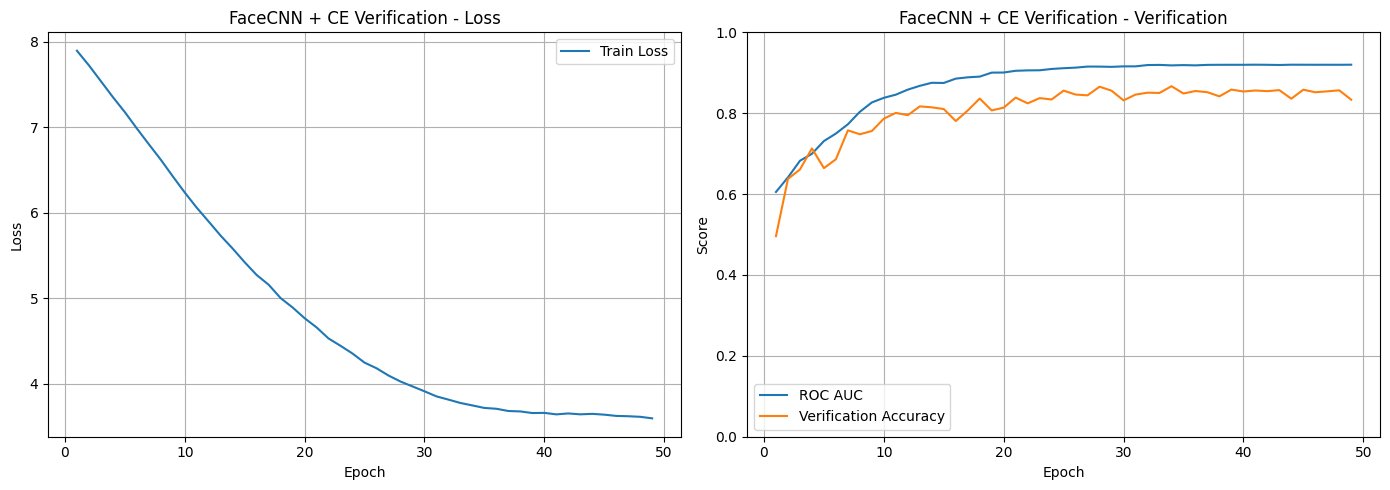

In [17]:
backbone = FaceCNN(embedding_dim=512)
head = LinearHead(embedding_dim=512, num_classes=NUM_CLASSES)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    list(backbone.parameters())+
    list(head.parameters()),
    lr=1e-4,
    weight_decay=5e-4
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=40,
    eta_min=1e-6
)

history, head, backbone = Trainer(
    backbone,
    head,
    optimizer,
    criterion,
    scheduler=scheduler,
    device=device,
    patience=8,
    save_dir="weights_ce"
).fit(
    train_loader,
    valid_loader,
    num_epochs=1000
)
plot_history( history, title="FaceCNN + CE Verification" )
del backbone, head,  optimizer, criterion, # scheduler,

### 7.2 Тренировка с ArcFace Head

Epoch [   1/1000] | same: 0.3240 | diff: 0.2355
Loss: 17.2269 | AUC: 0.5422 | ACC: 0.6259 | Thr: 0.831 | LR: 9.98e-05 | ES: 0/8 | 58.6s | Best Model State was Saved
Epoch [   2/1000] | same: 0.5814 | diff: 0.4979
Loss: 16.9319 | AUC: 0.5517 | ACC: 0.5642 | Thr: 0.913 | LR: 9.94e-05 | ES: 0/8 | 58.8s | Best Model State was Saved
Epoch [   3/1000] | same: 0.5342 | diff: 0.3341
Loss: 16.7566 | AUC: 0.6093 | ACC: 0.5519 | Thr: 0.688 | LR: 9.86e-05 | ES: 0/8 | 59.1s | Best Model State was Saved
Epoch [   4/1000] | same: 0.3653 | diff: 0.1127
Loss: 16.6053 | AUC: 0.6253 | ACC: 0.6645 | Thr: 0.558 | LR: 9.76e-05 | ES: 0/8 | 59.1s | Best Model State was Saved
Epoch [   5/1000] | same: 0.4392 | diff: 0.1893
Loss: 16.4759 | AUC: 0.6382 | ACC: 0.6838 | Thr: 0.616 | LR: 9.62e-05 | ES: 0/8 | 60.0s | Best Model State was Saved
Epoch [   6/1000] | same: 0.4536 | diff: 0.1716
Loss: 16.3428 | AUC: 0.6606 | ACC: 0.6864 | Thr: 0.565 | LR: 9.46e-05 | ES: 0/8 | 60.0s | Best Model State was Saved
Epoch [   

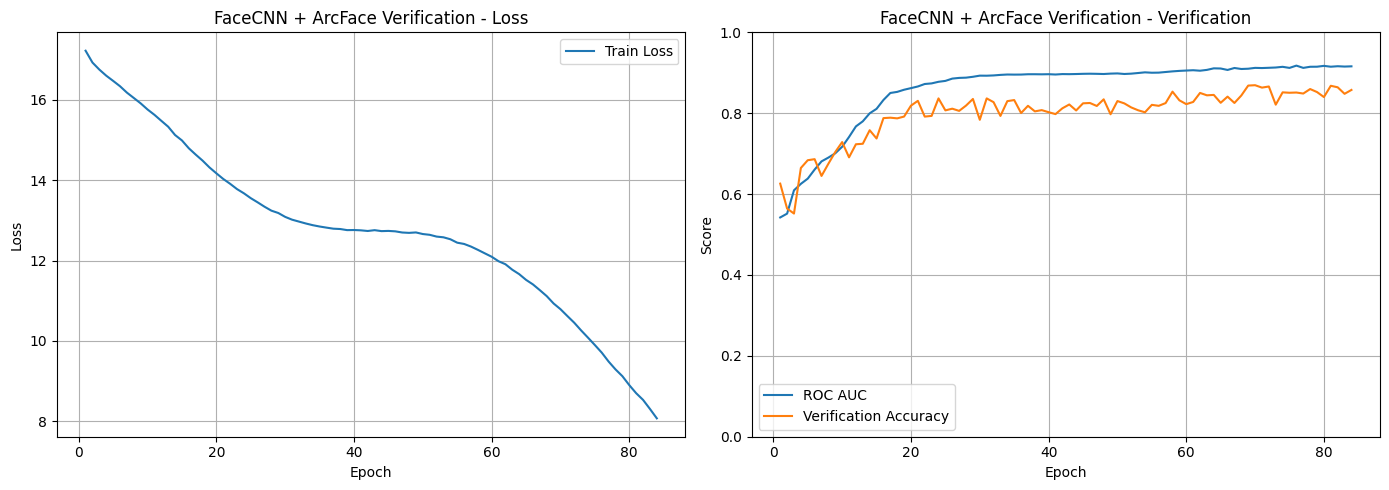

In [18]:
backbone = FaceCNN(embedding_dim=512)
head = ArcFaceHead(embedding_dim=512, num_classes=NUM_CLASSES, s=30, m=0.3)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    list(backbone.parameters())+
    list(head.parameters()),
    lr=1e-4,
    weight_decay=5e-4
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=40,
    eta_min=1e-6
)

history, head, backbone = Trainer(
    backbone,
    head,
    optimizer,
    criterion,
    scheduler=scheduler,
    device=device,
    patience=8,
    save_dir="weights_arcface"
).fit(
    train_loader,
    valid_loader,
    num_epochs=1000
)
plot_history( history, title="FaceCNN + ArcFace Verification" )
del backbone, head,  optimizer, criterion, # scheduler,

### Сравнение моделей FaceCNN + LinearHead и FaceCNN + ArcFaceHead
В ходе работы были обучены две модели на базе **FaceCNN**: первая использовала стандартную **CrossEntropyLoss**, вторая — **ArcFace**. 

Для оценки качества использовалась **verification accuracy** — доля правильно классифицированных пар изображений после выбора оптимального порога по **cosine similarity**. 

Дополнительно рассчитывалась метрика **ROC AUC** — характеризует способность модели разделять пары изображений одного и разных людей независимо от выбранного порога.

Обе модели превысили требуемую точность 0.7 на задаче верификации лиц. 

Модель с CrossEntropy достигла максимального **ROC AUC** 0.9200, а модель с **ArcFace** показала немного более высокую **verification accuracy** — 0.8693. 

Полученные результаты подтверждают, что обе функции потерь позволяют успешно обучать модель распознавания лиц, при этом ArcFace обеспечивает сопоставимое качество и ориентирована на формирование более дискриминативного пространства эмбеддингов.

Во всех экспериментах использовались одинаковые параметры оптимизации:

* Optimizer — AdamW
* learning rate — 1e-4
* weight decay — 5e-4
* scheduler — CosineAnnealingLR
* backbone — FaceCNN (embedding=512)

---

## 1. LinearHead (CrossEntropy)

### Динамика обучения

Обучение проходило стабильно и практически монотонно.

За первые 20 эпох наблюдался быстрый рост качества:

* AUC:

  * 0.605 → 0.900
* Accuracy:

  * 0.496 → 0.814

После примерно **25–30 эпох** качество практически вышло на плато.

Максимальные показатели:

* **ROC AUC = 0.9200**
* **Verification Accuracy = 0.8668**

---

### Поведение cosine similarity

Средние значения cosine similarity постепенно разделились.

Для одинаковых людей:

```
same ≈ 0.50
```

Для разных людей:

```
diff ≈ 0.006–0.01
```

Получился большой разрыв

```
0.50 - 0.01 ≈ 0.49
```

что говорит о хорошем разделении пространств эмбеддингов.

Оптимальный порог постепенно стабилизировался около

```
threshold ≈ 0.25
```

---

## 2. ArcFaceHead

### Динамика обучения

Обучение также проходило устойчиво.

Рост качества происходил несколько медленнее в начале, однако обучение продолжалось значительно дольше без выхода на насыщение.

Максимальные показатели:

* **ROC AUC = 0.9177**
* **Verification Accuracy = 0.8693**

По Accuracy ArcFace немного превзошёл обычную классификационную голову.

---

### Поведение cosine similarity

Средние значения постепенно изменялись следующим образом.

В начале обучения

```
same ≈ 0.32
diff ≈ 0.24
```

что говорит о практически полном отсутствии разделения классов.

К концу обучения

```
same ≈ 0.37
diff ≈ 0.01
```

Полученный разрыв

```
0.37 - 0.01 ≈ 0.36
```

меньше, чем у LinearHead, однако распределения стали значительно более компактными.

Оптимальный порог постепенно уменьшался

```
0.83 → 0.15–0.20
```

что связано с особенностями ArcFace и нормализацией эмбеддингов.

---

# Сравнение результатов

| Метрика               | LinearHead |    ArcFace |
| --------------------- | ---------: | ---------: |
| Лучший ROC AUC        | **0.9200** |     0.9177 |
| Лучшая Accuracy       |     0.8668 | **0.8693** |
| Разрыв same/diff      |  **≈0.49** |      ≈0.36 |
| Скорость сходимости   |   **выше** |       ниже |
| Стабильность обучения |    высокая |    высокая |

---

# Анализ результатов

По итоговым значениям обе модели показали практически одинаковое качество.

**LinearHead**

Преимущества:

* быстрее обучается;
* быстрее достигает максимального качества;
* показывает немного более высокий ROC AUC;
* формирует хорошо разделённые кластеры эмбеддингов.

Недостаток:

* обучение ориентировано только на задачу классификации и не учитывает напрямую угловое расстояние между эмбеддингами.

---

**ArcFace**

Преимущества:

* обеспечивает немного более высокую точность верификации (Accuracy);
* оптимизирует эмбеддинги непосредственно в угловом пространстве;
* обычно лучше переносится на новые личности и датасеты, не участвовавшие в обучении.

Недостатки:

* обучение происходит медленнее;
* требует более аккуратного подбора гиперпараметров (`s`, `m`, learning rate);
* на данном наборе данных не показал преимущества по ROC AUC.

---

# Вывод

В проведённом эксперименте обе модели достигли близких результатов. Модель **FaceCNN + LinearHead** показала немного лучший показатель **ROC AUC (0.9200 против 0.9177)** и более быстрое достижение плато качества. В свою очередь, модель **FaceCNN + ArcFaceHead** обеспечила немного более высокую **verification accuracy (0.8693 против 0.8668)**, что свидетельствует о более эффективном разделении пар изображений при оптимальном пороге.

Различия между моделями оказались менее **0.3%**, поэтому статистически они практически эквивалентны на данном датасете. С практической точки зрения выбор зависит от дальнейшего применения модели: если требуется максимальная скорость обучения и высокая метрика ROC AUC, предпочтительнее использовать **LinearHead**. Если же модель планируется применять для задач **face verification** или **face recognition** на ранее не встречавшихся пользователях, более перспективным является **ArcFace**, поскольку его функция потерь специально предназначена для формирования дискриминативного пространства эмбеддингов и обычно обеспечивает лучшую обобщающую способность.
